# 👁️ Diabetic Retinopathy Screener
### EfficientNet-B4 + Ordinal Regression + Grad-CAM

**Dataset:** APTOS 2019 Blindness Detection  
**Task:** 5-class DR severity grading (0 = No DR → 4 = Proliferative DR)  
**Metric:** Quadratic Weighted Kappa (QWK)  

---
### Pipeline Overview
```
Raw Fundus Image
      ↓
Preprocessing (Circle Crop + Green Channel + CLAHE)
      ↓
Augmentation (train only)
      ↓
EfficientNet-B4 Backbone (pretrained ImageNet)
      ↓
Custom Head (Pool → BN → Drop → Dense → BN → Drop → 1)
      ↓
Ordinal Regression Score (0.0 - 4.0)
      ↓
Round to Grade (0, 1, 2, 3, 4)
      ↓
Grad-CAM Heatmap
```

## Block 0 — Install Dependencies

In [1]:
# Install required libraries not available by default on Kaggle
!pip install -q timm grad-cam albumentations --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 48.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 83.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60

## Block 1 — Imports & Setup

In [2]:
# ── Core Libraries ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path

# ── PyTorch Core ─────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── EfficientNet via timm ─────────────────────────────────────
import timm

# ── Augmentation ─────────────────────────────────────────────
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Metrics ──────────────────────────────────────────────────
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import StratifiedKFold

# ── Grad-CAM ──────────────────────────────────────────────────
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import RawScoresOutputTarget

# ── Utilities ────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

# ── Device Setup ─────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"timm version: {timm.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128
timm version: 1.0.27


## Block 2 — Configuration
All hyperparameters in one place — easy to tune later

In [3]:
# ── Config ────────────────────────────────────────────────────
class CFG:
    # Paths
    BASE_PATH  = Path('/kaggle/input/competitions/aptos2019-blindness-detection')
    TRAIN_CSV  = BASE_PATH / 'train.csv'
    TEST_CSV   = BASE_PATH / 'test.csv'
    TRAIN_IMG  = BASE_PATH / 'train_images'
    TEST_IMG   = BASE_PATH / 'test_images'
    
    # Image
    IMAGE_SIZE = 384        # 384x384 — balances detail vs Kaggle memory
    
    # Model
    MODEL_NAME = 'efficientnet_b4'
    PRETRAINED = True
    
    # Training
    EPOCHS     = 40
    BATCH_SIZE = 16         # safe for Kaggle T4/P100 with 384x384
    LR         = 1e-4
    MIN_LR     = 1e-6
    WEIGHT_DECAY = 1e-5
    NUM_FOLDS  = 5
    FOLD       = 0          # which fold to train on
    NUM_WORKERS = 2
    
    # CLAHE
    CLIP_LIMIT    = 2.0     # validated default for retinal imaging
    TILE_GRID     = (8, 8)  # 48x48 pixels per tile at 384x384
    
    # Dropout
    DROP1 = 0.4             # stronger — high dimensional layer
    DROP2 = 0.2             # lighter  — compressed layer
    
    # Labels
    GRADE_LABELS = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
    NUM_CLASSES  = 5
    
    # Output
    SAVE_PATH = 'best_model.pth'

print("Configuration loaded ✅")

Configuration loaded ✅


## Block 3 — Data Loading & EDA

In [4]:
# ── Load CSVs ─────────────────────────────────────────────────
df      = pd.read_csv(CFG.TRAIN_CSV)
test_df = pd.read_csv(CFG.TEST_CSV)

print("Train shape:", df.shape)
print("Test shape: ", test_df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nClass Distribution:")
dist = df['diagnosis'].value_counts().sort_index()
for grade, count in dist.items():
    bar = '█' * (count // 50)
    pct = count / len(df) * 100
    print(f"Grade {grade} ({CFG.GRADE_LABELS[grade]:>16s}): {count:4d} {bar} {pct:.1f}%")

Train shape: (3662, 2)
Test shape:  (1928, 1)

First 5 rows:
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0

Class Distribution:
Grade 0 (           No DR): 1805 ████████████████████████████████████ 49.3%
Grade 1 (            Mild):  370 ███████ 10.1%
Grade 2 (        Moderate):  999 ███████████████████ 27.3%
Grade 3 (          Severe):  193 ███ 5.3%
Grade 4 (Proliferative DR):  295 █████ 8.1%


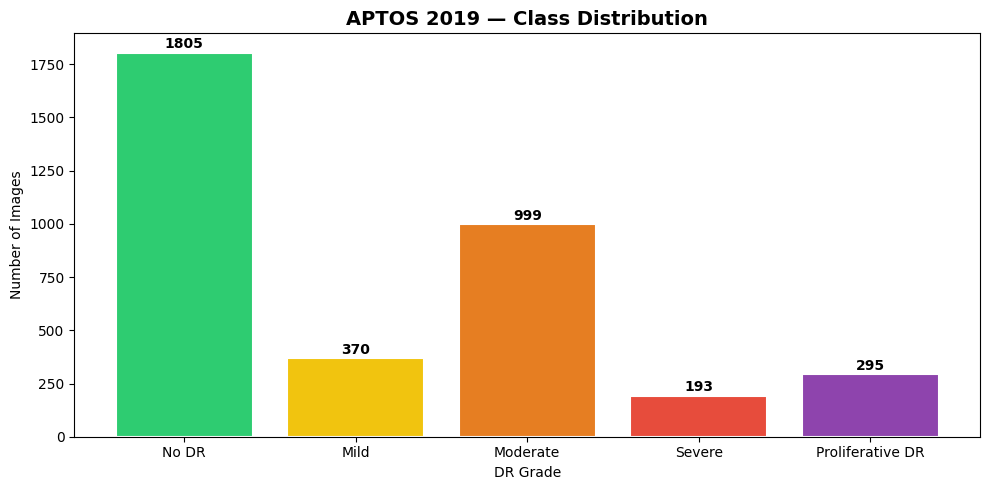


⚠️  Class Imbalance Detected — Grade 0 dominates (49%)
Strategy: Augmentation + Class Weighted Loss


In [5]:
# ── Visualize Class Distribution ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']

bars = ax.bar(
    CFG.GRADE_LABELS,
    df['diagnosis'].value_counts().sort_index(),
    color=colors,
    edgecolor='white',
    linewidth=1.5
)

for bar, count in zip(bars, df['diagnosis'].value_counts().sort_index()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        str(count),
        ha='center', fontweight='bold'
    )

ax.set_title('APTOS 2019 — Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Images')
ax.set_xlabel('DR Grade')
plt.tight_layout()
plt.show()

print("\n⚠️  Class Imbalance Detected — Grade 0 dominates (49%)")
print("Strategy: Augmentation + Class Weighted Loss")

## Block 4 — Preprocessing Pipeline

**Why each step:**
- **Circle Crop** → removes black border noise from fundus camera
- **Green Channel** → highest contrast for blood vessel lesions
- **CLAHE** → local contrast enhancement, reveals microaneurysms
- **Stack 3x** → EfficientNet expects 3-channel input

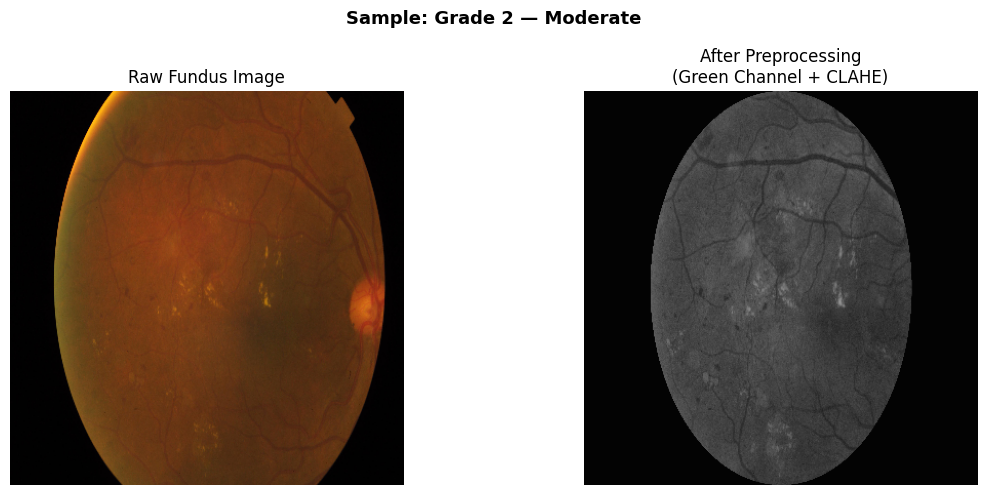

In [6]:
def preprocess_image(image_path, image_size=CFG.IMAGE_SIZE):
    """
    Preprocess a retinal fundus image.
    Steps: Read → Circle Crop → Green Channel → CLAHE → Stack → Resize
    """
    # ── Step 1: Read Image ─────────────────────────────────────
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # ── Step 2: Circle Crop ────────────────────────────────────
    # Fundus images are circular — corners are black noise
    height, width = img.shape[:2]
    cx, cy        = width // 2, height // 2
    radius        = min(cx, cy)
    mask          = np.zeros((height, width), dtype=np.uint8)
    cv2.circle(mask, (cx, cy), radius, 255, -1)
    img           = cv2.bitwise_and(img, img, mask=mask)
    
    # ── Step 3: Green Channel ──────────────────────────────────
    # Green channel shows highest contrast for retinal lesions
    # img shape: (H, W, 3) → channels 0=R, 1=G, 2=B
    green = img[:, :, 1]   # shape: (H, W)
    
    # ── Step 4: CLAHE ──────────────────────────────────────────
    # Local contrast enhancement — each tile enhanced independently
    # clipLimit=2.0 → validated default for retinal imaging
    # tileGridSize=(8,8) → 48x48 pixel tiles at 384x384
    clahe    = cv2.createCLAHE(
        clipLimit   = CFG.CLIP_LIMIT,
        tileGridSize= CFG.TILE_GRID
    )
    enhanced = clahe.apply(green)
    
    # ── Step 5: Stack to 3 channels ────────────────────────────
    # EfficientNet expects (H, W, 3) — we duplicate green channel
    # Preserves pretrained ImageNet weights compatibility
    enhanced_3ch = np.stack([enhanced, enhanced, enhanced], axis=-1)
    
    # ── Step 6: Resize ─────────────────────────────────────────
    final = cv2.resize(enhanced_3ch, (image_size, image_size))
    
    return final  # shape: (384, 384, 3), dtype: uint8


# ── Visualize Preprocessing ────────────────────────────────────
sample_path = CFG.TRAIN_IMG / (df['id_code'][0] + '.png')

raw = cv2.cvtColor(cv2.imread(str(sample_path)), cv2.COLOR_BGR2RGB)
raw = cv2.resize(raw, (384, 384))
processed = preprocess_image(sample_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(raw)
axes[0].set_title('Raw Fundus Image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(processed)
axes[1].set_title('After Preprocessing\n(Green Channel + CLAHE)', fontsize=12)
axes[1].axis('off')

plt.suptitle(f'Sample: Grade {df["diagnosis"][0]} — {CFG.GRADE_LABELS[df["diagnosis"][0]]}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Block 5 — Augmentation Strategy

**Train:** flips + rotations + distortions + normalize  
**Val/Test:** normalize only (no augmentation — consistent evaluation)

In [7]:
def get_transforms(phase):
    """
    Returns Albumentations transform pipeline.
    Train: augmentation + normalize + tensor
    Val  : normalize + tensor only
    
    Normalize with ImageNet stats — EfficientNet pretrained on ImageNet,
    weights calibrated to expect inputs in this exact range.
    """
    # ImageNet mean & std — required for pretrained EfficientNet
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]
    
    if phase == 'train':
        return A.Compose([
            # ── Geometric Augmentations ───────────────────────
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(
                shift_limit  = 0.0625,
                scale_limit  = 0.1,
                rotate_limit = 45,
                p=0.5
            ),
            # ── Distortion Augmentations ──────────────────────
            A.OneOf([
                A.GridDistortion(p=1.0),
                A.OpticalDistortion(p=1.0),
            ], p=0.3),
            # ── Color Augmentations ───────────────────────────
            A.ColorJitter(
                brightness = 0.2,
                contrast   = 0.2,
                p=0.3
            ),
            # ── Normalize & Convert ───────────────────────────
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2()        # numpy (H,W,C) → torch tensor (C,H,W)
        ])
    
    else:  # val / test
        return A.Compose([
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2()
        ])

print("Transforms defined ✅")
print("Train: augmentation + normalize + ToTensor")
print("Val  : normalize + ToTensor only")

Transforms defined ✅
Train: augmentation + normalize + ToTensor
Val  : normalize + ToTensor only


## Block 6 — Dataset Class

**Three required methods in every PyTorch Dataset:**
- `__init__`    → stores data
- `__len__`     → total samples
- `__getitem__` → returns one sample by index

In [8]:
class APTOSDataset(Dataset):
    """
    PyTorch Dataset for APTOS 2019.
    
    Args:
        df        : DataFrame with id_code and diagnosis columns
        img_dir   : Path to image folder
        transform : Albumentations transforms (optional)
        is_test   : If True, returns image only (no label)
                    Default=False because most usage is training
    """
    
    # ── ① __init__ — store everything we need ──────────────────
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df        = df
        self.img_dir   = img_dir
        self.transform = transform   # optional — safe default None
        self.is_test   = is_test     # test CSV has no labels
    
    # ── ② __len__ — how many samples total? ────────────────────
    def __len__(self):
        return len(self.df)
    
    # ── ③ __getitem__ — give me sample number idx ───────────────
    def __getitem__(self, idx):
        
        # Build image path
        img_id   = self.df.iloc[idx]['id_code']
        img_path = self.img_dir / f"{img_id}.png"
        
        # Preprocess (Circle Crop + Green Channel + CLAHE)
        image = preprocess_image(img_path)
        
        # Apply augmentations if provided
        if self.transform:
            augmented = self.transform(image=image)
            image     = augmented['image']
        
        # Test set — no labels
        if self.is_test:
            return image
        
        # float32 because ordinal regression uses MSE loss
        # MSE needs continuous values — not integer class indices
        label = torch.tensor(
            self.df.iloc[idx]['diagnosis'],
            dtype=torch.float32
        )
        
        return image, label


# ── Quick Test ─────────────────────────────────────────────────
test_ds  = APTOSDataset(df.head(5), CFG.TRAIN_IMG,
                        transform=get_transforms('val'))
img, lbl = test_ds[0]
print(f"Dataset test ✅")
print(f"Image tensor shape : {img.shape}")
print(f"Label              : {lbl.item()} ({CFG.GRADE_LABELS[int(lbl.item())]})")
print(f"Label dtype        : {lbl.dtype}  ← float32 for MSE loss")

Dataset test ✅
Image tensor shape : torch.Size([3, 384, 384])
Label              : 2.0 (Moderate)
Label dtype        : torch.float32  ← float32 for MSE loss


## Block 7 — Train/Val Split & DataLoaders

In [9]:
# ── Stratified K-Fold Split ────────────────────────────────────
# Stratified = maintains class distribution in every fold
# If overall 49% Grade 0 → each fold train/val also ~49% Grade 0
skf = StratifiedKFold(
    n_splits   = CFG.NUM_FOLDS,
    shuffle    = True,
    random_state = SEED
)

for fold, (train_idx, val_idx) in enumerate(
        skf.split(df, df['diagnosis'])):
    if fold == CFG.FOLD:
        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df   = df.iloc[val_idx].reset_index(drop=True)
        break

print(f"Fold {CFG.FOLD} Split:")
print(f"  Train: {len(train_df)} images")
print(f"  Val  : {len(val_df)} images")
print(f"\nTrain class distribution:")
print(train_df['diagnosis'].value_counts().sort_index())

# ── Create Datasets ────────────────────────────────────────────
train_dataset = APTOSDataset(
    train_df, CFG.TRAIN_IMG,
    transform = get_transforms('train')
)
val_dataset = APTOSDataset(
    val_df, CFG.TRAIN_IMG,
    transform = get_transforms('val')
)

# ── Create DataLoaders ─────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size  = CFG.BATCH_SIZE,
    shuffle     = True,
    num_workers = CFG.NUM_WORKERS,
    pin_memory  = True,
    drop_last   = True    # ← ADD THIS LINE
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = CFG.BATCH_SIZE,
    shuffle     = False,         # consistent order for reproducibility
    num_workers = CFG.NUM_WORKERS,
    pin_memory  = True
)

print(f"\nDataLoaders created ✅")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")

Fold 0 Split:
  Train: 2929 images
  Val  : 733 images

Train class distribution:
diagnosis
0    1444
1     296
2     799
3     154
4     236
Name: count, dtype: int64

DataLoaders created ✅
Train batches: 183
Val batches  : 46


## Block 8 — Class Weights

**Why:** Even after augmentation, class imbalance remains.  
Class weights assign higher loss penalty to rare grades (1, 3, 4).

In [10]:
# ── Manual Class Weights ──────────────────────────────────────
# WHY manual instead of inverse-frequency:
# Previous run showed model collapsing to Grade 2 for severe cases.
# Inverse-frequency gave Grade 3=2.02, Grade 4=1.32 — not enough.
# Manual weights aggressively boost Grade 3 (5.0) and Grade 4 (4.5)
# to force the model to pay serious attention to blindness-risk grades.
#
# Grade 0 = 0.5  → most common (49%), slight downweight
# Grade 1 = 2.0  → mild, moderate boost
# Grade 2 = 0.8  → model already over-predicts this, slight downweight
# Grade 3 = 5.0  → severe, heavily boosted — blindness risk if missed
# Grade 4 = 4.5  → proliferative, heavily boosted — most critical
MANUAL_WEIGHTS = [0.5, 2.0, 0.8, 5.0, 4.5]
class_weights  = torch.tensor(MANUAL_WEIGHTS, dtype=torch.float32).to(device)

print("Class weights (manual — aggressive minority boost):")
for i, (label, w) in enumerate(
        zip(CFG.GRADE_LABELS, class_weights.cpu().numpy())):
    bar = '█' * int(w * 4)
    print(f"  Grade {i} ({label:>16s}): {w:.1f}  {bar}")

Class weights (manual — aggressive minority boost):
  Grade 0 (           No DR): 0.5  ██
  Grade 1 (            Mild): 2.0  ████████
  Grade 2 (        Moderate): 0.8  ███
  Grade 3 (          Severe): 5.0  ████████████████████
  Grade 4 (Proliferative DR): 4.5  ██████████████████


## Block 9 — Model Architecture

**EfficientNet-B4** — chosen for:
- Large enough to capture fine retinal lesions at 384×384
- Not so large that it overfits 3662-image dataset
- Compound scaling (depth + width + resolution together)

**Gradual Unfreezing strategy:**
- Phase 1: Train head only (backbone frozen)
- Phase 2: Unfreeze last 2 blocks
- Phase 3: Unfreeze full network

In [11]:
class DRModel(nn.Module):
    
    def __init__(self, pretrained=True):
        super(DRModel, self).__init__()
        
        # ── Backbone ───────────────────────────────────────────
        # num_classes=0 → timm removes its head AND applies
        # global average pooling internally
        # Output shape: (B, 1792) — already flat
        self.backbone = timm.create_model(
            CFG.MODEL_NAME,
            pretrained    = pretrained,
            num_classes   = 0,
            global_pool   = 'avg'   # ← explicit pooling inside timm
        )
        
        n_features = self.backbone.num_features  # 1792 for B4
        
        # ── Custom Head ────────────────────────────────────────
        # NO AdaptiveAvgPool2d — timm already pooled
        # NO Flatten — output is already (B, 1792)
        self.head = nn.Sequential(
                nn.BatchNorm1d(n_features),
                nn.Dropout(CFG.DROP1),
                nn.Linear(n_features, 256),
                nn.ReLU(),
                nn.BatchNorm1d(256),
                nn.Dropout(CFG.DROP2),
                nn.Linear(256, 1)
            )
    
    def forward(self, x):
        features = self.backbone(x)   # timm with num_classes=0
        output   = self.head(features)
        return output
    
    def freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False
        print("Backbone frozen ❄️  — training head only")
    
    def unfreeze_last_blocks(self, n=2):
        blocks = list(self.backbone.blocks)
        for block in blocks[-n:]:
            for param in block.parameters():
                param.requires_grad = True
        print(f"Last {n} blocks unfrozen 🔓")
    
    def unfreeze_all(self):
        for param in self.backbone.parameters():
            param.requires_grad = True
        print("Full network unfrozen 🔓🔓")


# ── Initialize ─────────────────────────────────────────────────
model = DRModel(pretrained=CFG.PRETRAINED).to(device)

# ── Verify shape ───────────────────────────────────────────────
dummy = torch.randn(2, 3, 384, 384).to(device)
out   = model(dummy)
print(f"✅ Model output shape: {out.shape}")  # should print (2, 1)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters()
                if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

✅ Model output shape: torch.Size([2, 1])
Total params    : 18,011,977
Trainable params: 18,011,977


## Block 10 — Training Setup

In [12]:
# ── Weighted MSE Loss ──────────────────────────────────────────
# Combines ordinal regression (MSE) + class imbalance correction
class WeightedMSELoss(nn.Module):
    """
    MSE loss with per-sample class weights.
    Rare grade mistakes penalized more heavily.
    """
    def __init__(self, class_weights):
        super().__init__()
        self.class_weights = class_weights
    
    def forward(self, outputs, targets):
        # Get weight for each sample based on its true grade
        weights = self.class_weights[targets.long().squeeze()]
        # Weighted MSE: w * (pred - true)²
        loss    = weights * (outputs.squeeze() - targets.squeeze()) ** 2
        return loss.mean()

criterion = WeightedMSELoss(class_weights)

# ── Optimizer ─────────────────────────────────────────────────
# Adam: adaptive learning rate per parameter
# weight_decay: L2 regularization — another overfitting defense
optimizer = optim.Adam(
    model.parameters(),
    lr           = CFG.LR,
    weight_decay = CFG.WEIGHT_DECAY
)

# ── Cosine Annealing Scheduler ─────────────────────────────────
# lr decreases following cosine curve: 1e-4 → 1e-6
# Fast early (exploring) → slow late (fine-tuning)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max   = CFG.EPOCHS,
    eta_min = CFG.MIN_LR
)

print("Training setup complete ✅")
print(f"Loss      : WeightedMSELoss (Ordinal Regression + Class Weights)")
print(f"Optimizer : Adam (lr={CFG.LR}, wd={CFG.WEIGHT_DECAY})")
print(f"Scheduler : CosineAnnealingLR ({CFG.LR} → {CFG.MIN_LR} over {CFG.EPOCHS} epochs)")

Training setup complete ✅
Loss      : WeightedMSELoss (Ordinal Regression + Class Weights)
Optimizer : Adam (lr=0.0001, wd=1e-05)
Scheduler : CosineAnnealingLR (0.0001 → 1e-06 over 40 epochs)


## Block 11 — Training & Validation Loops

**5 steps of every training iteration (memorize this):**
1. `zero_grad()` — clear accumulated gradients
2. Forward pass — model predicts
3. Compute loss — how wrong?
4. `backward()` — compute gradients
5. `step()` — update weights

In [13]:
def train_epoch(model, loader, optimizer, criterion, device):
    """
    One full training epoch.
    Returns: (loss, QWK)
    """
    model.train()           # Dropout active, BatchNorm uses batch stats
    running_loss = 0
    all_preds    = []
    all_labels   = []
    
    for batch_idx, (images, labels) in enumerate(loader):
        
        # ── Move to GPU ────────────────────────────────────────
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)  # (B,) → (B, 1)
        
        # ── Step 1: Zero Gradients ─────────────────────────────
        # PyTorch accumulates gradients — must clear each batch
        optimizer.zero_grad()
        
        # ── Step 2: Forward Pass ───────────────────────────────
        outputs = model(images)              # shape: (B, 1)
        
        # ── Step 3: Compute Loss ───────────────────────────────
        loss = criterion(outputs, labels)
        
        # ── Step 4: Backward Pass ──────────────────────────────
        loss.backward()                      # compute gradients
        
        # ── Step 5: Update Weights ─────────────────────────────
        optimizer.step()
        
        # ── Track Metrics ──────────────────────────────────────
        running_loss += loss.item()
        
        # detach() — remove from computation graph (no need for gradients)
        # cpu()    — move back to CPU (numpy only works on CPU)
        preds = outputs.detach().cpu().numpy().flatten()
        preds = np.clip(np.round(preds), 0, 4)  # round + clip to valid range
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy().flatten())
    
    epoch_loss = running_loss / len(loader)
    epoch_qwk  = cohen_kappa_score(
        np.array(all_labels).astype(int),
        np.array(all_preds).astype(int),
        weights='quadratic'
    )
    return epoch_loss, epoch_qwk


def val_epoch(model, loader, criterion, device):
    """
    One full validation epoch.
    Returns: (loss, QWK)
    
    Key differences from train_epoch:
    - model.eval()        → Dropout off, BatchNorm uses running stats
    - torch.no_grad()     → no gradient computation → faster + less memory
    - no optimizer steps  → we're just evaluating, not learning
    """
    model.eval()            # Dropout disabled, BatchNorm uses running stats
    running_loss = 0
    all_preds    = []
    all_labels   = []
    
    with torch.no_grad():   # no gradient computation needed in validation
        for images, labels in loader:
            
            images  = images.to(device)
            labels  = labels.to(device).unsqueeze(1)
            
            outputs = model(images)
            loss    = criterion(outputs, labels)
            
            running_loss += loss.item()
            preds  = outputs.cpu().numpy().flatten()
            preds  = np.clip(np.round(preds), 0, 4)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy().flatten())
    
    epoch_loss = running_loss / len(loader)
    epoch_qwk  = cohen_kappa_score(
        np.array(all_labels).astype(int),
        np.array(all_preds).astype(int),
        weights='quadratic'
    )
    return epoch_loss, epoch_qwk

print("Train and validation loop functions defined ✅")

Train and validation loop functions defined ✅


## Block 12 — Full Training Runner with Gradual Unfreezing

In [14]:
def train_model(model, train_loader, val_loader,
                optimizer, scheduler, criterion,
                device, epochs=CFG.EPOCHS):
    """
    Full training loop with gradual unfreezing.
    
    Gradual Unfreezing Strategy:
    - Phase 1 (epochs 1-5)  : Head only — backbone frozen
    - Phase 2 (epochs 6-15) : Last 2 blocks unfrozen
    - Phase 3 (epochs 16-30): Full network unfrozen
    
    Why: Preserves useful ImageNet features (edges, textures)
         while slowly adapting to retinal domain
    """
    best_qwk   = -1
    best_epoch = 0
    history    = {
        'train_loss': [], 'val_loss': [],
        'train_qwk' : [], 'val_qwk' : [],
        'lr'        : []
    }
    
    # ── Phase 1: Freeze backbone ───────────────────────────────
    model.freeze_backbone()
    
    for epoch in range(epochs):
        
        # ── Gradual Unfreezing Schedule ────────────────────────
        if epoch == 5:
            print("\n--- Phase 2: Unfreezing last 2 blocks ---")
            model.unfreeze_last_blocks(n=2)
            # Lower lr for unfrozen pretrained weights
            for pg in optimizer.param_groups:
                pg['lr'] = CFG.LR * 0.1
        
        if epoch == 15:
            print("\n--- Phase 3: Unfreezing full network ---")
            model.unfreeze_all()
            for pg in optimizer.param_groups:
                pg['lr'] = CFG.LR * 0.01
        
        # ── Train ──────────────────────────────────────────────
        train_loss, train_qwk = train_epoch(
            model, train_loader, optimizer, criterion, device)
        
        # ── Validate ───────────────────────────────────────────
        val_loss, val_qwk = val_epoch(
            model, val_loader, criterion, device)
        
        # ── Scheduler Step ─────────────────────────────────────
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()
        
        # ── Save Best Model ────────────────────────────────────
        # Save state_dict only — weights without architecture
        # Portable, lightweight, version-independent
        if val_qwk > best_qwk:
            best_qwk   = val_qwk
            best_epoch = epoch + 1
            torch.save(model.state_dict(), CFG.SAVE_PATH)
            saved_str = " ✅ BEST SAVED"
        else:
            saved_str = ""
        
        # ── Log ────────────────────────────────────────────────
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_qwk'].append(train_qwk)
        history['val_qwk'].append(val_qwk)
        history['lr'].append(current_lr)
        
        print(f"Epoch {epoch+1:02d}/{epochs} "
              f"| LR: {current_lr:.1e} "
              f"| Train Loss: {train_loss:.4f} "
              f"| Val Loss: {val_loss:.4f} "
              f"| Train QWK: {train_qwk:.4f} "
              f"| Val QWK: {val_qwk:.4f}"
              f"{saved_str}")
    
    print(f"\n{'='*60}")
    print(f"Training Complete!")
    print(f"Best Val QWK: {best_qwk:.4f} at Epoch {best_epoch}")
    print(f"{'='*60}")
    
    return history


# ── Run Training ───────────────────────────────────────────────
print("Starting training...")
print(f"Epochs: {CFG.EPOCHS} | Batch: {CFG.BATCH_SIZE} | Image: {CFG.IMAGE_SIZE}x{CFG.IMAGE_SIZE}")
print(f"Device: {device}")
print("=" * 60)

history = train_model(
    model, train_loader, val_loader,
    optimizer, scheduler, criterion,
    device, epochs=CFG.EPOCHS
)

Starting training...
Epochs: 40 | Batch: 16 | Image: 384x384
Device: cuda
Backbone frozen ❄️  — training head only
Epoch 01/40 | LR: 1.0e-04 | Train Loss: 4.6073 | Val Loss: 3.1145 | Train QWK: 0.5718 | Val QWK: 0.6988 ✅ BEST SAVED
Epoch 02/40 | LR: 1.0e-04 | Train Loss: 3.6942 | Val Loss: 3.1857 | Train QWK: 0.6648 | Val QWK: 0.6944
Epoch 03/40 | LR: 9.9e-05 | Train Loss: 3.1902 | Val Loss: 2.2279 | Train QWK: 0.6947 | Val QWK: 0.7826 ✅ BEST SAVED
Epoch 04/40 | LR: 9.9e-05 | Train Loss: 2.7832 | Val Loss: 2.0586 | Train QWK: 0.7254 | Val QWK: 0.7927 ✅ BEST SAVED
Epoch 05/40 | LR: 9.8e-05 | Train Loss: 2.6294 | Val Loss: 1.5696 | Train QWK: 0.7238 | Val QWK: 0.7950 ✅ BEST SAVED

--- Phase 2: Unfreezing last 2 blocks ---
Last 2 blocks unfrozen 🔓
Epoch 06/40 | LR: 1.0e-05 | Train Loss: 2.2888 | Val Loss: 1.6792 | Train QWK: 0.7527 | Val QWK: 0.8061 ✅ BEST SAVED
Epoch 07/40 | LR: 9.8e-06 | Train Loss: 2.2996 | Val Loss: 1.9979 | Train QWK: 0.7380 | Val QWK: 0.8095 ✅ BEST SAVED
Epoch 08/40

## Block 13 — Training Curves

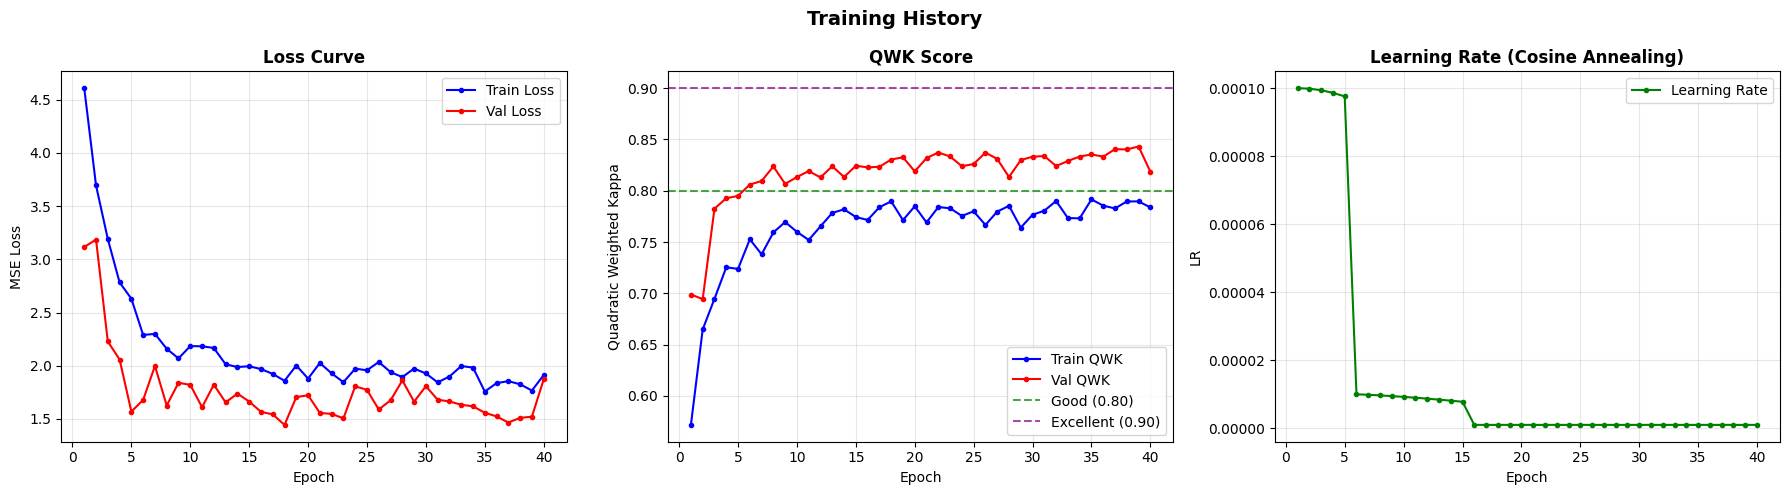

In [15]:
def plot_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = range(1, len(history['train_loss']) + 1)
    
    # ── Loss ──────────────────────────────────────────────────
    axes[0].plot(epochs, history['train_loss'], 'b-o',
                 label='Train Loss', markersize=3)
    axes[0].plot(epochs, history['val_loss'], 'r-o',
                 label='Val Loss', markersize=3)
    axes[0].set_title('Loss Curve', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # ── QWK ───────────────────────────────────────────────────
    axes[1].plot(epochs, history['train_qwk'], 'b-o',
                 label='Train QWK', markersize=3)
    axes[1].plot(epochs, history['val_qwk'], 'r-o',
                 label='Val QWK', markersize=3)
    axes[1].axhline(y=0.80, color='g', linestyle='--',
                    alpha=0.7, label='Good (0.80)')
    axes[1].axhline(y=0.90, color='purple', linestyle='--',
                    alpha=0.7, label='Excellent (0.90)')
    axes[1].set_title('QWK Score', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Quadratic Weighted Kappa')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # ── Learning Rate ─────────────────────────────────────────
    axes[2].plot(epochs, history['lr'], 'g-o',
                 label='Learning Rate', markersize=3)
    axes[2].set_title('Learning Rate (Cosine Annealing)',
                      fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('LR')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.suptitle('Training History', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(history)

## Block 14 — Load Best Model & Evaluate

In [16]:
# ── Load Best Weights ──────────────────────────────────────────
# state_dict() — loads weights only, not architecture
# map_location ensures compatibility across CPU/GPU environments
model.load_state_dict(
    torch.load(CFG.SAVE_PATH, map_location=device)
)
print(f"Best model loaded from {CFG.SAVE_PATH} ✅")

# ── Final Evaluation ───────────────────────────────────────────
val_loss, val_qwk = val_epoch(model, val_loader, criterion, device)
print(f"\nFinal Validation Results:")
print(f"  Val Loss : {val_loss:.4f}")
print(f"  Val QWK  : {val_qwk:.4f}")

# QWK Interpretation
if val_qwk >= 0.90:
    level = "🏆 Excellent — Publication level"
elif val_qwk >= 0.80:
    level = "✅ Very Good"
elif val_qwk >= 0.60:
    level = "⚠️  Good — Room for improvement"
else:
    level = "❌ Needs improvement"
    
print(f"  Level    : {level}")

Best model loaded from best_model.pth ✅

Final Validation Results:
  Val Loss : 1.5218
  Val QWK  : 0.8431
  Level    : ✅ Very Good


## Block 15 — Grad-CAM Explainability

**What Grad-CAM does:**  
Uses gradients flowing into the last convolutional layer to generate a heatmap showing *which retinal regions* (microaneurysms, hemorrhages) drove the severity prediction.

**Why it matters clinically:**  
Doctors can see *why* the model predicted a specific grade — builds trust and enables verification.

Generating Grad-CAM visualizations...

Grade 0 — No DR


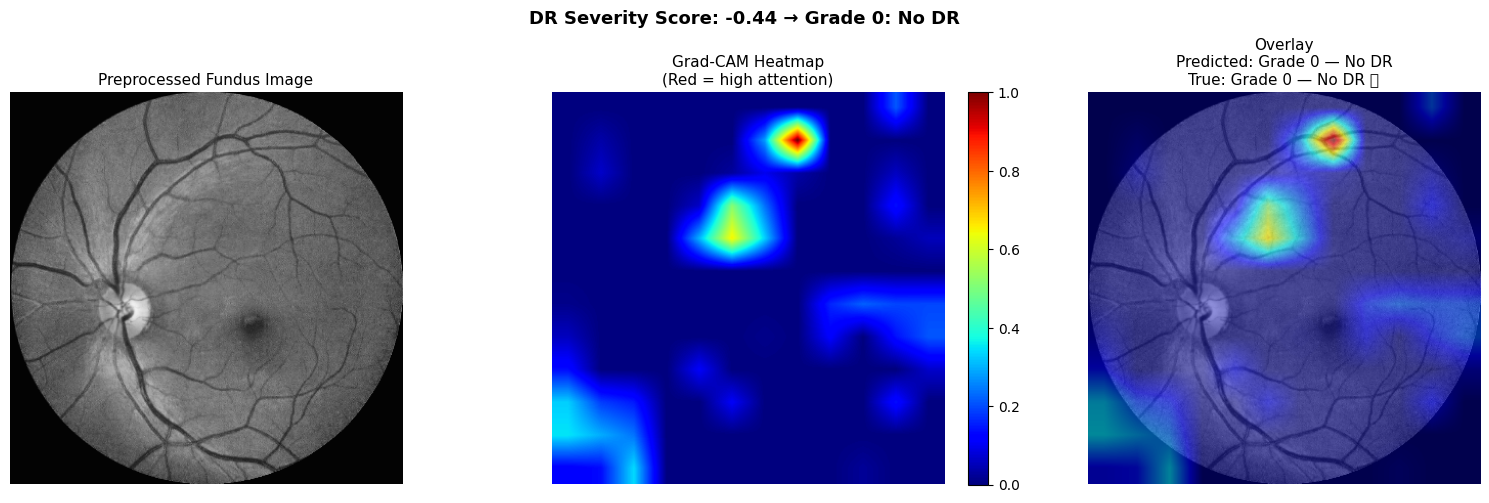

Grade 1 — Mild


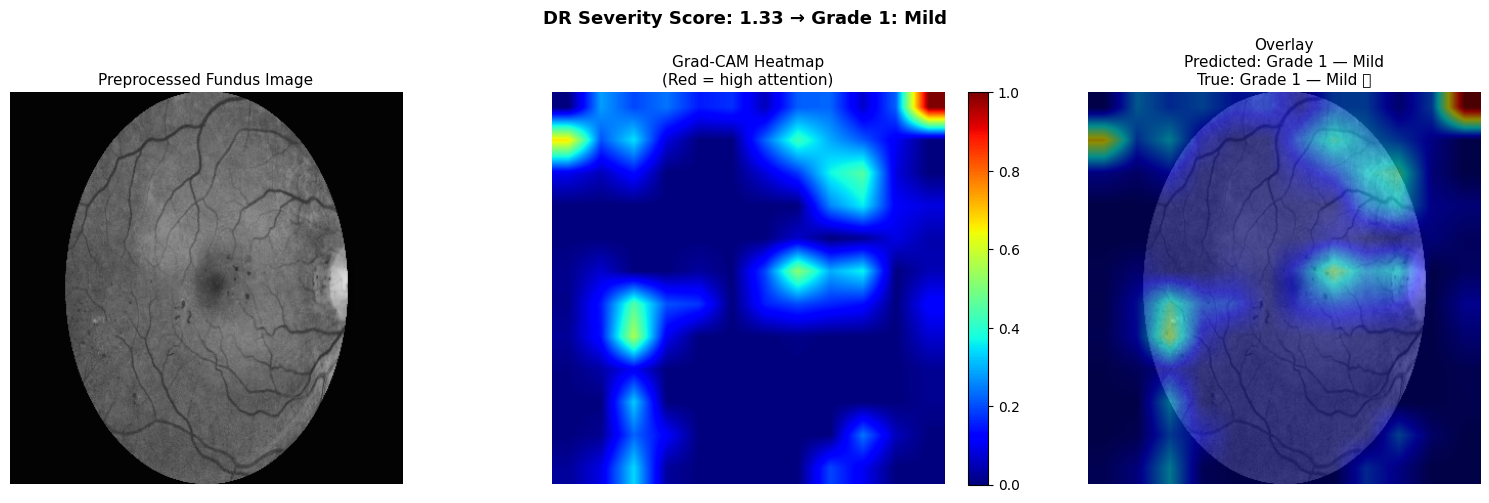

Grade 2 — Moderate


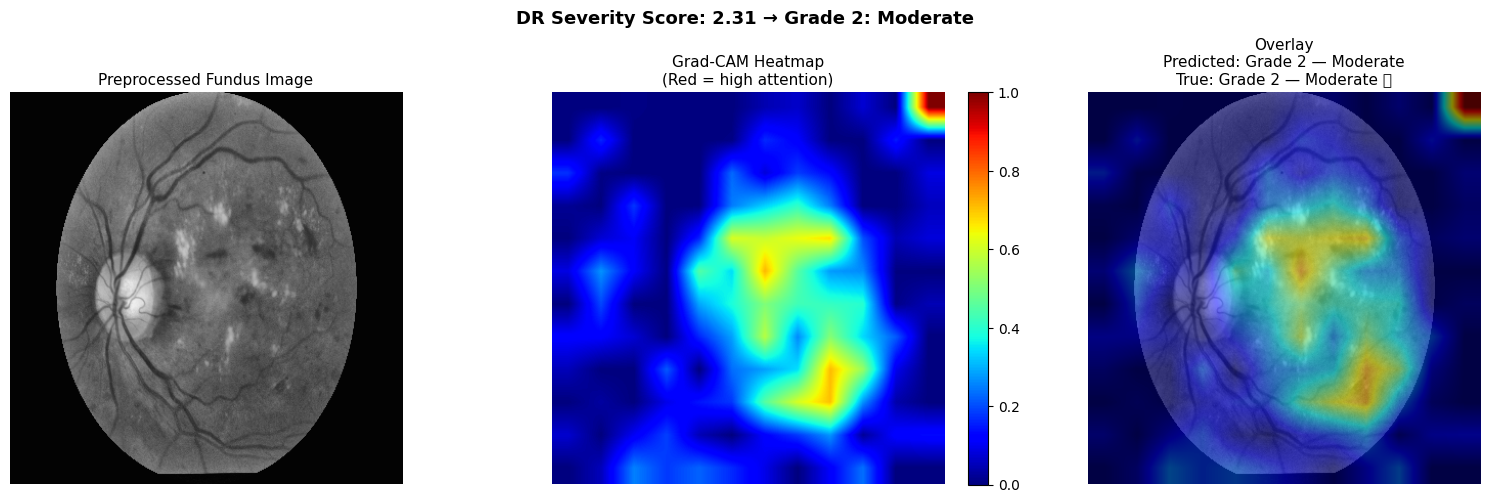

Grade 3 — Severe


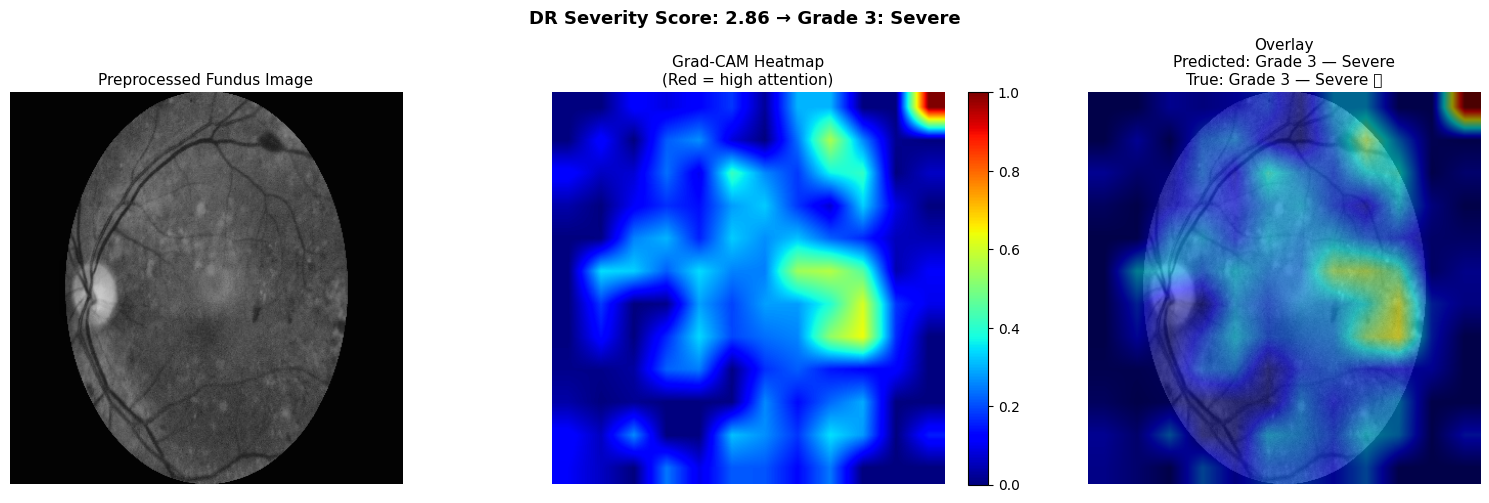

Grade 4 — Proliferative DR


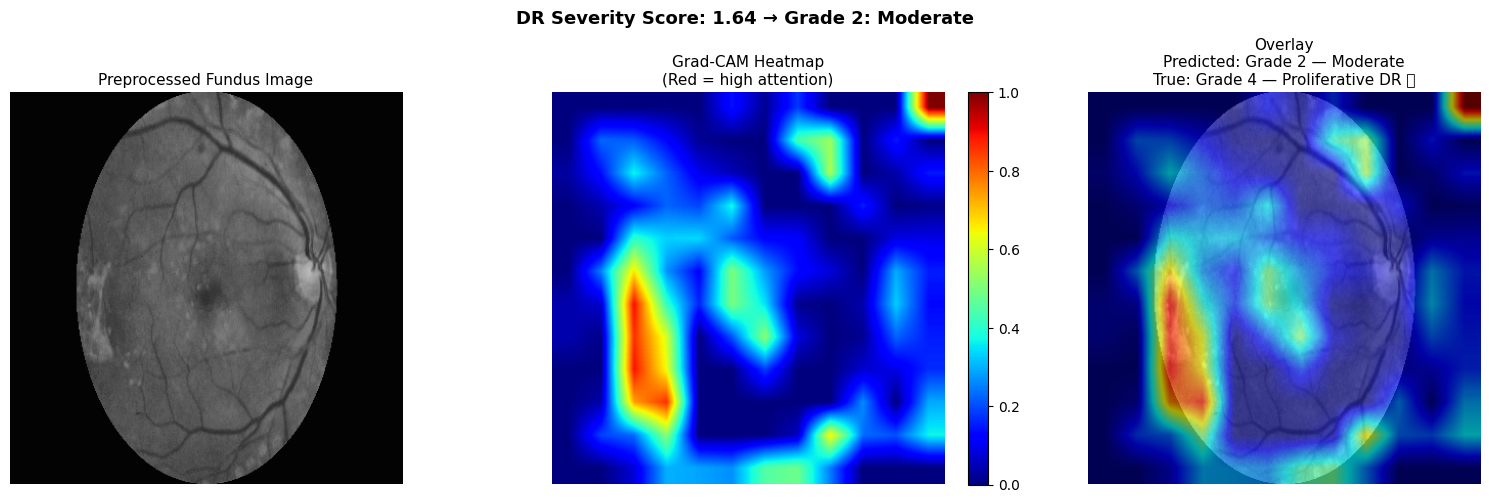

In [17]:
def generate_gradcam(model, image_path, device, true_grade=None):
    """
    Generate Grad-CAM heatmap for a single fundus image.
    
    Args:
        model      : trained DRModel
        image_path : path to fundus image
        device     : cuda or cpu
        true_grade : optional ground truth for comparison
    
    Returns:
        predicted_grade, cam_mask
    """
    # ── Preprocess ────────────────────────────────────────────
    image     = preprocess_image(image_path)
    transform = get_transforms('val')
    tensor    = transform(image=image)['image']
    tensor    = tensor.unsqueeze(0).to(device)   # (3,384,384) → (1,3,384,384)
    
    # ── Get Prediction ────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        output = model(tensor)
        score  = output.cpu().item()
        grade  = int(np.clip(round(score), 0, 4))
    
    # ── Grad-CAM Setup ────────────────────────────────────────
    # Target: last convolutional block
    # Why last? Deepest layer = most task-specific features
    # Early layers: generic edges → Last layer: DR-specific patterns
    target_layer = [model.backbone.blocks[-1]]
    cam          = GradCAM(model=model, target_layers=target_layer)
    targets      = [RawScoresOutputTarget()]
    
    # ── Generate Heatmap ──────────────────────────────────────
    mask          = cam(input_tensor=tensor, targets=targets)
    mask          = mask[0]                        # remove batch dim
    image_float   = image / 255.0                  # normalize 0-1 for overlay
    visualization = show_cam_on_image(
        image_float, mask, use_rgb=True
    )
    
    # ── Plot ──────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Original preprocessed image
    axes[0].imshow(image)
    axes[0].set_title('Preprocessed Fundus Image', fontsize=11)
    axes[0].axis('off')
    
    # Grad-CAM heatmap only
    axes[1].imshow(mask, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap\n(Red = high attention)', fontsize=11)
    axes[1].axis('off')
    
    # Overlay
    axes[2].imshow(visualization)
    title = f'Overlay\nPredicted: Grade {grade} — {CFG.GRADE_LABELS[grade]}'
    if true_grade is not None:
        match  = "✅" if grade == true_grade else "❌"
        title += f'\nTrue: Grade {true_grade} — {CFG.GRADE_LABELS[true_grade]} {match}'
    axes[2].set_title(title, fontsize=11)
    axes[2].axis('off')
    
    plt.suptitle(
        f'DR Severity Score: {score:.2f} → Grade {grade}: {CFG.GRADE_LABELS[grade]}',
        fontsize=13, fontweight='bold'
    )
    plt.colorbar(
        plt.cm.ScalarMappable(cmap='jet'),
        ax=axes[1],
        fraction=0.046
    )
    plt.tight_layout()
    plt.show()
    
    return grade, mask


# ── Run Grad-CAM on validation samples ────────────────────────
print("Generating Grad-CAM visualizations...\n")

# Show one sample from each DR grade
for target_grade in range(5):
    sample = val_df[val_df['diagnosis'] == target_grade]
    if len(sample) == 0:
        continue
    row        = sample.iloc[0]
    image_path = CFG.TRAIN_IMG / f"{row['id_code']}.png"
    
    print(f"Grade {target_grade} — {CFG.GRADE_LABELS[target_grade]}")
    pred_grade, _ = generate_gradcam(
        model, image_path, device,
        true_grade=target_grade
    )

## Block 16 — Complete Pipeline Summary

In [18]:
print("""
╔══════════════════════════════════════════════════════════════╗
║         👁️  DIABETIC RETINOPATHY SCREENER — SUMMARY         ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DECISIONS & RATIONALE:                                      ║
║                                                              ║
║  Dataset       → APTOS 2019 (3662 images, 5 classes)         ║
║  Imbalance     → Augmentation + Manual Class Weights         ║
║  Preprocessing → Circle Crop + Green Channel + CLAHE         ║
║  Input Size    → 384×384 (Kaggle memory constraint)          ║
║  Backbone      → EfficientNet-B4 (compound scaling)          ║
║  Fine-tuning   → Gradual Unfreezing (3 phases)               ║
║  Loss          → Weighted MSE (Ordinal Regression)           ║
║  Metric        → Quadratic Weighted Kappa (QWK)              ║
║  Optimizer     → Adam + CosineAnnealingLR                    ║
║  Explainability→ Grad-CAM on last conv block                 ║
║                                                              ║
║  OUTPUT:                                                     ║
║  ├── DR Grade (0-4)                                          ║
║  ├── Severity Label (No DR → Proliferative)                  ║
║  └── Grad-CAM heatmap (visual evidence for doctor)           ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         👁️  DIABETIC RETINOPATHY SCREENER — SUMMARY         ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DECISIONS & RATIONALE:                                      ║
║                                                              ║
║  Dataset       → APTOS 2019 (3662 images, 5 classes)         ║
║  Imbalance     → Augmentation + Manual Class Weights         ║
║  Preprocessing → Circle Crop + Green Channel + CLAHE         ║
║  Input Size    → 384×384 (Kaggle memory constraint)          ║
║  Backbone      → EfficientNet-B4 (compound scaling)          ║
║  Fine-tuning   → Gradual Unfreezing (3 phases)               ║
║  Loss          → Weighted MSE (Ordinal Regression)           ║
║  Metric        → Quadratic Weighted Kappa (QWK)              ║
║  Optimizer     → Adam + CosineAnnealingLR                    ║
║  Explainability→ Grad-C

## Block 18 — ONNX Export → TFLite Conversion

**Deployment pipeline:**
```
PyTorch best_model.pth
      ↓
ONNX format (opset 11) — framework-agnostic
      ↓
TFLite with INT8 quantization — mobile-ready
      ↓
Target: Redmi Note 14 5G (Android 16)
```
**Expected size:** ~75MB PyTorch → ~20MB after INT8 quantization

In [19]:
# ── Block 18: ONNX Export + TFLite Conversion ─────────────────
import os

# ── Step 1: Load best model ────────────────────────────────────
print("Loading best model...")
export_model = DRModel(pretrained=False).to(device)
export_model.load_state_dict(torch.load(CFG.SAVE_PATH, map_location=device))
export_model.eval()   # CRITICAL: eval mode for export (Dropout off)
print(f"Model loaded from {CFG.SAVE_PATH} ✅")

# ── Step 2: PyTorch → ONNX ────────────────────────────────────
# dummy_input simulates one 384x384 RGB image
# opset_version=11 — widely supported, safe choice
ONNX_PATH = 'visionguard_dr.onnx'
dummy_input = torch.randn(1, 3, CFG.IMAGE_SIZE, CFG.IMAGE_SIZE).to(device)

print("\nExporting to ONNX...")
torch.onnx.export(
    export_model,
    dummy_input,
    ONNX_PATH,
    opset_version    = 11,
    input_names      = ['fundus_image'],     # meaningful name for Android
    output_names     = ['dr_grade_score'],   # continuous ordinal score
    dynamic_axes     = {                     # allow variable batch size
        'fundus_image'    : {0: 'batch_size'},
        'dr_grade_score'  : {0: 'batch_size'}
    }
)
onnx_size_mb = os.path.getsize(ONNX_PATH) / (1024 * 1024)
print(f"ONNX export complete ✅")
print(f"ONNX model size: {onnx_size_mb:.1f} MB")

# ── Step 3: Verify ONNX model ─────────────────────────────────
try:
    import onnx
    onnx_model = onnx.load(ONNX_PATH)
    onnx.checker.check_model(onnx_model)
    print("ONNX model verified ✅")
except ImportError:
    print("onnx not installed — run: pip install onnx")
    print("Skipping verification, export likely still OK")

# ── Step 4: ONNX → TFLite with INT8 quantization ──────────────
# Requires: pip install onnx-tf tensorflow
# INT8 quantization: weights stored as 8-bit integers
# Effect: ~75MB → ~20MB, faster inference on mobile CPU
TFLITE_PATH = 'visionguard_dr_int8.tflite'

try:
    import subprocess
    # Install conversion tools if not present
    subprocess.run(['pip', 'install', '-q', 'onnx-tf', 'tensorflow'], check=True)
    
    import tensorflow as tf
    from onnx_tf.backend import prepare
    import onnx
    
    print("\nConverting ONNX → TensorFlow SavedModel...")
    onnx_model = onnx.load(ONNX_PATH)
    tf_rep = prepare(onnx_model)
    tf_rep.export_graph('visionguard_saved_model')
    
    print("Converting TensorFlow SavedModel → TFLite (INT8)...")
    converter = tf.lite.TFLiteConverter.from_saved_model('visionguard_saved_model')
    
    # INT8 quantization — shrinks model ~4x, faster on mobile
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    
    tflite_model = converter.convert()
    
    with open(TFLITE_PATH, 'wb') as f:
        f.write(tflite_model)
    
    tflite_size_mb = os.path.getsize(TFLITE_PATH) / (1024 * 1024)
    print(f"\nTFLite conversion complete ✅")
    print(f"Original PyTorch : ~75 MB")
    print(f"ONNX             : {onnx_size_mb:.1f} MB")
    print(f"TFLite INT8      : {tflite_size_mb:.1f} MB  ← deploy this to Android")
    print(f"\nFiles saved:")
    print(f"  {ONNX_PATH}")
    print(f"  {TFLITE_PATH}  ← copy this to your Android app assets/")

except Exception as e:
    print(f"\nTFLite conversion failed: {e}")
    print("\nManual fallback — run these commands:")
    print("  pip install onnx-tf tensorflow")
    print("  Then re-run this cell")
    print(f"\nONNX file is ready at: {ONNX_PATH} ({onnx_size_mb:.1f} MB)")
    print("Use Neutron or Netron to inspect the ONNX graph if needed.")

Loading best model...
Model loaded from best_model.pth ✅

Exporting to ONNX...


ModuleNotFoundError: No module named 'onnxscript'